In [59]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

#### Problem Description
The post-COVID transition to hybrid lifestyles has redistributed the high-income workforce into lower-cost, residential neighborhoods. This migration has accelerated transnational gentrification, leading to significant shifts in local cost-of-living metrics. We will model this transnational gentrification, where high-income remote workers displace local residents through purchasing power asymmetry. Using coupled ordinary differential equations, we will analyze equilibrium conditions, stability, and effectiveness of policy interventions like rental caps and visa quotas through bifurcation analysis.

#### Variables & Parameters
| Description | Symbol | Dimensions | Type |
| :--- | :--- | :--- | :--- |
| Population of "locals" in a city | $L_n(t)$ | T | variable |
| Population of "nomads" in a city | $N_n(t)$ | T | variable |
| A neighborhood's Average Cost of Living | $P_n(t)$ | $\$$ | variable |
| The authenticity of a city | $A_n(t)$ | - | variable |
| Total number of cities | $N$ | - | parameter |
| Local population growth rate | $\alpha$ | - | parameter |
| Local population displacement sensitivity | $\beta$ | - | parameter |
| Local income | $I_L$ | - | parameter |
| Nomads purchasing power over the locals | $\sigma$ | - | parameter | 
| Sensitivity of price to number of residents | $\kappa$ | - | parameter |

#### Assumptions (tentative list)
- "Nomads" move to cities with higher authenticity. 
- "Locals" move to cities with lower average cost of living.
- Average cost of living is controlled by the number of "nomads" to "locals" ratio 

#### Model

We will consider this model to be a *Predator-Prey* model. In this case, the "Nomads" are the predators and the "Locals" are the prey that generate the main resource absorbed by the predators, "Authenticity". For simplicity, we will say that the average cost of living and authenticity in a city are given by the algebraic equations. 
$$
P(t) = P_0 + \kappa(L(t) + \sigma N(t)), \quad A(t) = \frac{L(t)}{L(t)+N(t)}
$$
and define the change in local and nomad population in any single city as the equations (Notation: we will be dropping the independent variable from $L,N,P,$ and $A$ from here on)
$$
\begin{align}
\frac{dL}{dt} &= \alpha L - \beta\left(\frac{P}{ I_L}\right)L \implies \frac{dL}{dt} = \alpha L - \beta\left(\frac{P_0 + \kappa L + \kappa\sigma N)}{I_L}\right)L\\
\frac{dN}{dt} &= \delta A N - \gamma N \implies \frac{dN}{dt} = \delta \left(\frac{L}{L+N}\right) N - \gamma N  
\end{align}
$$

#### Nondimensionalization

Let 
$$
t = \hat{t}\tau, \quad L = \hat{L}x, \quad N = \hat{N}y
$$
where $\hat{t}, \hat{L}, \hat{N}$ are the scaling factors. Then the scaled system is
$$
\begin{align}
\frac{\hat{L}}{\hat{t}} \frac{dx}{d\tau} &= \left(\alpha - \frac{\beta P_0}{I_L}\right)\hat{L}x - \left(\frac{\beta \kappa}{I_L}\right) (\hat{L}x)^2 - \left(\frac{\beta \kappa \sigma}{I_L}\right) (\hat{L}x)(\hat{N}y) \\
\frac{\hat{N}}{\hat{t}} \frac{dy}{d\tau} &= \delta \left(\frac{\hat{L}x}{\hat{L}x + \hat{N}y}\right) \hat{N}y - \gamma \hat{N} y
\end{align}
$$
then
$$
\begin{align}
\frac{dx}{d\tau} &= \left(\alpha - \frac{\beta P_0}{I_L}\right) \hat{t}x - \left(\frac{\beta \kappa}{I_L}\right) \hat{t}\hat{L}x^2 - \left(\frac{\beta \kappa \sigma}{I_L}\right) \hat{t}x (\hat{N}y) \\
\frac{dy}{d\tau} &= \delta \left(\frac{\hat{L}x}{\hat{L}x + \hat{N}y}\right) \hat{t}y - \gamma \hat{t}y
\end{align}
$$

Now choose
$$
\hat{L}=\hat{N}=\frac{I_L\gamma}{\beta \kappa}, \quad \hat{t} = \frac{1}{\gamma}
$$
and for ease of reading 
$$
\rho = \left(\frac{\alpha-\beta (P_0/L)}{\gamma}\right), \quad \mu = \frac{\delta}{\gamma}
$$
so the nondimensionalized system is
$$
\begin{align}
\frac{dx}{d\tau} &= x(\rho  - x - \sigma y) \\
\frac{dy}{d\tau} &= y\left(\mu \left(\frac{x}{x + y}\right)-1\right)
\end{align}
$$


quick analysis of the non dimensionless parameters
- $\rho:$ The numerator is the growth rate $\alpha$ minus the "decay" of the local population, almost acting like the "total net growth rate of the city". This is divided by $\gamma$ the parameter associated with nomads leaving a city. $\rho$ then measures the ratio of locals leaving the city over nomads leaving the city. if $\rho < 0$ then both populations are leaving the city indicating the price is too expensive. if $\rho > 0$ then the city is affordable for both populations.
- $\mu:$ The numerator $\delta$ is the parameter associated with how authentic a city is this is divided by $\gamma$ the rate at which nomads leave a city, the overall ratio describes how fast nomads leave a city, if $\mu <1$ then nomads are leaving the city faster than they are being attracted to it. if $\mu > 1$ then lots of nomads are attracted to the city.
- $\sigma:$ Sigma represents the purchasing price difference between locals and nomads, its supposed to represent a multiplier of buying power, that is if $\sigma=3$ then the nomads have three times the purchasing power.

In [60]:
# parameters
rho = 1.0    # net local growth rate
mu = 2.0      # nomad attraction-to-departure ratio
sigma = 3.0   # purchasing power multiplier

# define RHS of the ODE
def f(u,t):
    dudt = np.zeros(2)
    x, y = u[0], u[1]
    if x + y == 0:
        dudt[0] = rho * x
        dudt[1] = -y
        return dudt
    dudt[0] = x * (rho - x - sigma * y)
    dudt[1] = y * (mu * x / (x + y) - 1)
    return dudt

# equilibrium values (derived by hand in the report)
x_star = rho / (1 + (mu - 1) * sigma)
y_star = (mu - 1) * rho / (1 + (mu - 1) * sigma)

## Phase Portrait

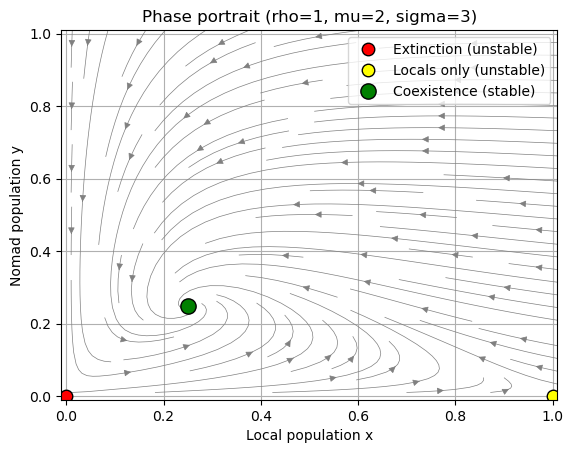

In [61]:
# vector field grid
xvals = np.linspace(0.01, 1.01, 25)
yvals = np.linspace(0.01, 1.01, 25)
X, Y = np.meshgrid(xvals, yvals)

DX = X * (rho - X - sigma * Y)
DY = Y * (mu * X / (X + Y) - 1)

# plot
plt.figure()
plt.streamplot(X, Y, DX, DY, color='grey', linewidth=0.5)

plt.plot(0, 0, 'o', color='red', markersize=9,
         markeredgecolor='black', label='Extinction (unstable)')
plt.plot(rho, 0, 'o', color='yellow', markersize=9,
         markeredgecolor='black', label='Locals only (unstable)')
plt.plot(x_star, y_star, 'o', color='green', markersize=11,
         markeredgecolor='black', label='Coexistence (stable)')

plt.xlabel('Local population x')
plt.ylabel('Nomad population y')
plt.title('Phase portrait (rho=1, mu=2, sigma=3)')
plt.legend(loc='upper right')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid()
plt.savefig('phase_portrait.png', dpi=200, bbox_inches='tight')
plt.show()

## Time Series

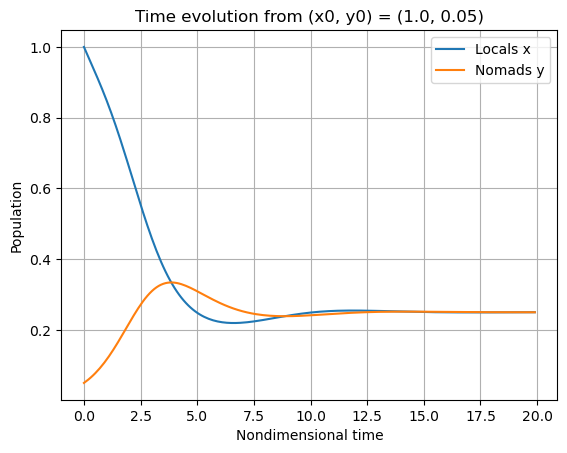

In [62]:
# parameters
tmax = 20
dt = 0.1

# initial condition: neighbourhood at local carrying capacity, small nomad population
u0 = [1.0, 0.05]

# set up time vector
t = np.arange(0, tmax, dt)

# integrate the ODEs
u = spi.odeint(f, u0, t)

# plot solution
plt.figure()
plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.xlabel('Nondimensional time')
plt.ylabel('Population')
plt.title('Time evolution from (x0, y0) = (1.0, 0.05)')
plt.legend()
plt.grid()
plt.savefig('time_series.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_21503/303967063.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[0] = x * (rho - x - sigma * y)


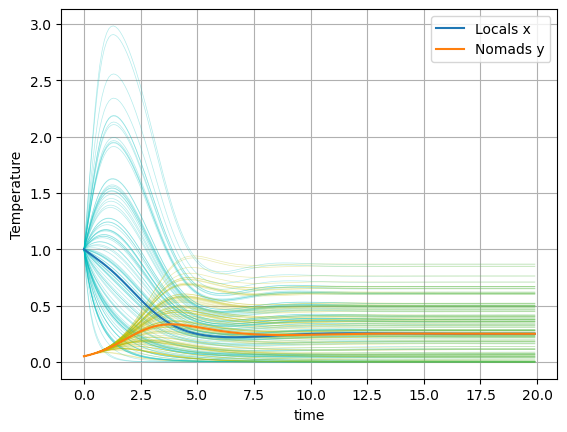

In [63]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

for i in range(N):
    rho = 1.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:,0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:,1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.legend()
plt.grid(True)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_21503/303967063.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[1] = y * (mu * x / (x + y) - 1)


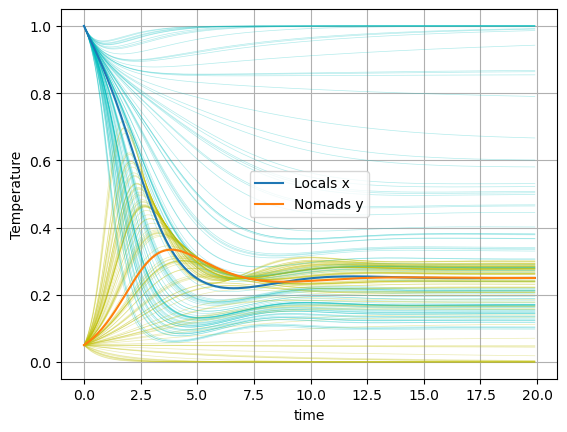

In [64]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

rho = 1.0
sigma = 3.0

for i in range(N):
    mu = 2.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:, 0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:, 1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.legend()
plt.grid(True)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_21503/303967063.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[0] = x * (rho - x - sigma * y)


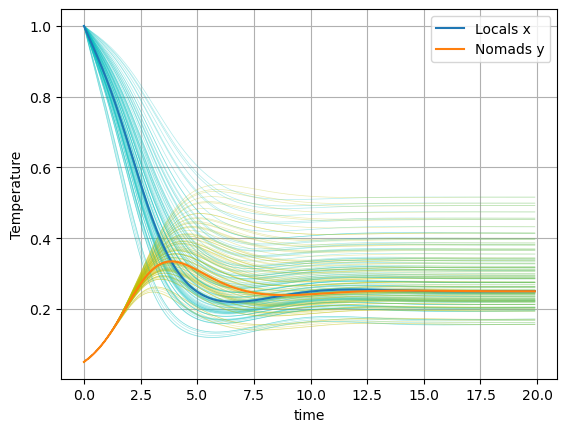

In [65]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

rho = 1.0
mu = 2.0

for i in range(N):
    sigma = 3.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:,0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:,1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.legend()
plt.grid(True)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.show()